## Check that the Window Dataset class works

In [1]:
import os
import pandas as pd
from tqdm import tqdm
if os.getcwd().endswith("notebooks"):
    os.chdir("../")

from src.embeddings.dataset import WindowDataset, WindowDatasetTCN
from src.embeddings.train import train_autoencoder
from torch.utils.data import DataLoader
from src.embeddings.models import MotionAutoencoder, MotionAutoencoderOld

In [2]:
processed_path = "data/processed"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("10fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

# load df with where first column in csv serves as index
df_vid_name_map = pd.read_csv("data/scores/vid_name_map.csv", index_col=0)

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_10fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        participant_id = df_vid_name_map.loc[vid]['Participant Number']
        #if int(participant_id) == 8:
        #    continue
        df_dict[(vid, int(participant_id))] = pd.read_pickle(path)[cols_to_keep]
        pbar.update(1)

Loading processed data: 100%|██████████| 86/86 [00:10<00:00,  7.86it/s]


In [3]:
import random
random.seed(42)

validation_goups = random.sample(range(1, 30), 4)
#[1, 11, 17, 18]
train_groups = [g for g in range(1, 30) if (g not in validation_goups or g==8)]

train_df_dict = {key: df_dict[key] for key in df_dict.keys() if key[1] in train_groups}
val_df_dict = {key: df_dict[key] for key in df_dict.keys() if key[1] in validation_goups}

train_dataset = WindowDatasetTCN(
    df_dict=train_df_dict,
    window_size=30,
    step_size=10,
    hand="Right", 
    fps=10,
)

val_dataset = WindowDatasetTCN(
    df_dict=val_df_dict,
    window_size=30,
    step_size=10,
    hand="Right", 
    fps=10,
    scaling_stats=train_dataset.scaling_stats
)

Processing Right Hand Windows: 100%|██████████| 74/74 [00:00<00:00, 131.22it/s]


Computing robust scaling statistics from training data...


Processing Right Hand Windows: 100%|██████████| 12/12 [00:00<00:00, 123.60it/s]


In [8]:
import numpy as np

all_data = np.array([feats for feats, _ in train_dataset] + [feats for feats, _ in val_dataset])

# (N, T, C) -> (N x T, C)
all_data_reshaped = all_data.reshape(-1, all_data.shape[-1])

# turn into dataframe and describe
df_all_data = pd.DataFrame(all_data_reshaped, columns=["dx", "dy", "vx", "vy", "ax", "ay", "mask"])
df_all_data[df_all_data['mask']==1].describe()

,dx,dy,vx,vy,ax,ay,mask
count,1.008258e+06,1.008258e+06,1.008258e+06,1.008258e+06,1.008258e+06,1.008258e+06,1008258.0
mean,5.297564e-02,-2.845881e-02,5.297565e-02,-2.845882e-02,-2.533953e-02,-3.048693e-03,1.0
std,1.611857e+00,1.484290e+00,1.611857e+00,1.484292e+00,1.570315e+00,1.473782e+00,0.0
min,-5.000000e+00,-5.000000e+00,-5.000000e+00,-5.000000e+00,-5.000000e+00,-5.000000e+00,1.0
25%,-4.147691e-01,-4.606077e-01,-4.147691e-01,-4.606078e-01,-4.769448e-01,-4.841267e-01,1.0
50%,-5.668300e-03,0.000000e+00,-5.668301e-03,0.000000e+00,7.690538e-03,-7.917603e-03,1.0
75%,5.056925e-01,4.606012e-01,5.056926e-01,4.606013e-01,4.538239e-01,4.523799e-01,1.0
max,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,1.0


In [ ]:
# check proportion of clipped data
(df_all_data >= 4.99).sum() / len(df_all_data)

dx      0.022201
dy      0.013009
vx      0.022201
vy      0.013009
ax      0.017436
ay      0.013983
mask    0.000000
dtype: float64

# Training of AE

In [4]:
train_loader = DataLoader(train_dataset, batch_size=37, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

In [5]:
ae = MotionAutoencoder(feature_dim=7, latent_dim=16, dropout_prob=0.1).to("cpu")
best_model, _ = train_autoencoder(ae, train_loader, val_loader=val_loader, epochs=50, lr=0.0025)

Epoch 001: 100%|██████████| 804/804 [02:21<00:00,  5.70it/s]  


Epoch 001 — train: 12.642360 (rec:12.641900, aug:0.009596, cons:0.036360) | val: 13.909111


Epoch 002: 100%|██████████| 804/804 [00:07<00:00, 109.95it/s]


Epoch 002 — train: 11.660602 (rec:11.659981, aug:0.008654, cons:0.053407) | val: 12.961457


Epoch 003: 100%|██████████| 804/804 [00:07<00:00, 113.34it/s]


...

Epoch 048 — train: 7.031333 (rec:7.030307, aug:0.005246, cons:0.097387) | val: 8.091296


Epoch 049: 100%|██████████| 804/804 [00:07<00:00, 113.07it/s]


Epoch 049 — train: 7.032549 (rec:7.031515, aug:0.005319, cons:0.097991) | val: 8.096173


Epoch 050: 100%|██████████| 804/804 [00:06<00:00, 121.52it/s]


Epoch 050 — train: 7.032655 (rec:7.031617, aug:0.005266, cons:0.098570) | val: 8.096449


In [21]:
# save the trained autoencoder model
import torch
model_path = "results/models/motion_autoencoder.pth"
torch.save(ae.state_dict(), model_path)
print(f"Model saved to {model_path}")

Model saved to results/models/motion_autoencoder.pth


In [16]:
# check the distribution of the reconstucted data

ae.eval()
reconstructed_data = []
with torch.no_grad():
    for batch in val_loader:
        inputs, _ = batch
        outputs, _ = ae(inputs)
        reconstructed_data.append(outputs.numpy())

In [18]:
# (N, T, C) -> (N x T, C)
reconstructed_data = [data.reshape(-1, data.shape[-1]) for data in reconstructed_data]

df_validation_output = pd.DataFrame(np.concatenate(reconstructed_data, axis=0), columns=["dx", "dy", "vx", "vy", "ax", "ay"])
df_validation_output.describe()

,dx,dy,vx,vy,ax,ay
count,136800.000000,136800.000000,136800.000000,136800.000000,136800.000000,136800.000000
mean,0.083164,-0.066658,0.083163,-0.066659,0.024007,-0.094789
std,1.295579,1.169849,1.295578,1.169849,0.871288,0.806147
min,-7.859762,-8.288151,-7.859486,-8.288296,-7.490153,-7.053577
25%,-0.300992,-0.395452,-0.300996,-0.395466,-0.130426,-0.262219
50%,0.021643,-0.030674,0.021629,-0.030678,0.016553,-0.092959
75%,0.422161,0.278990,0.422149,0.278988,0.210689,0.048360
max,8.404857,7.564775,8.404736,7.564981,8.240515,7.201705


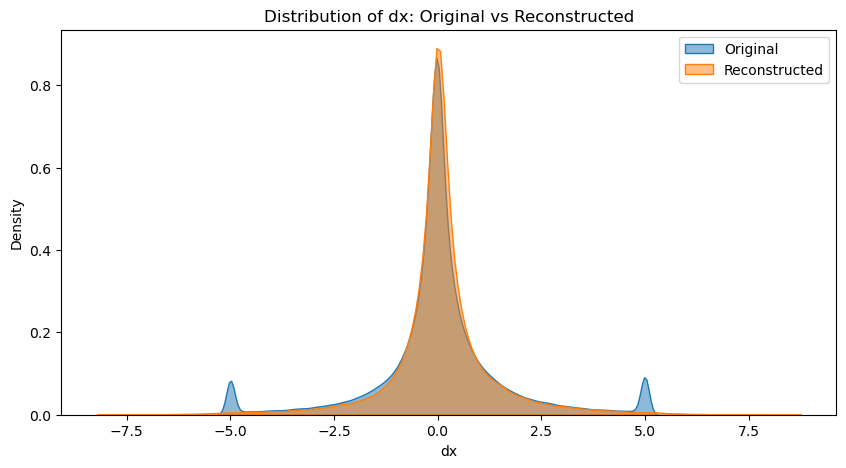

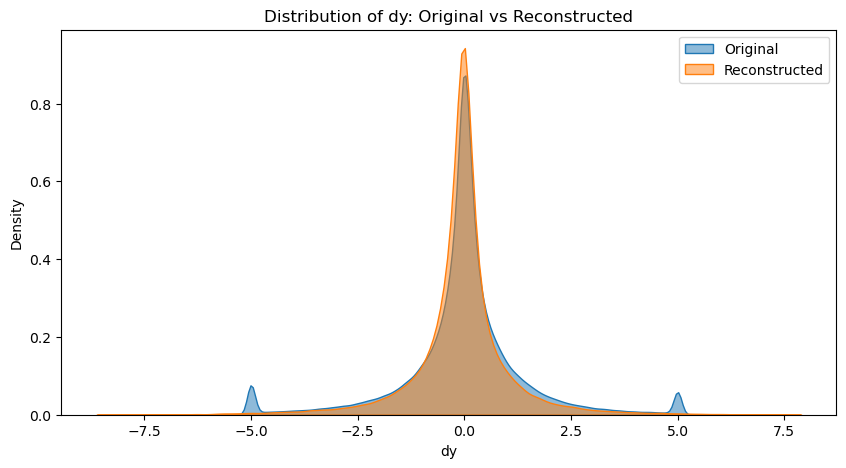

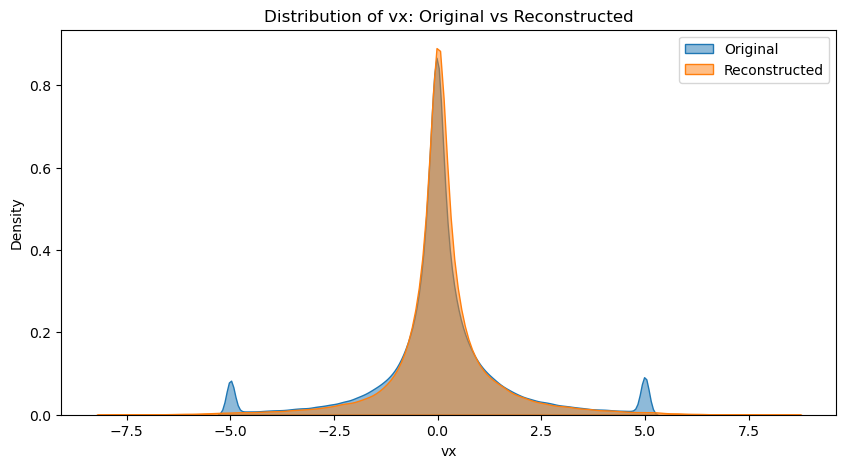

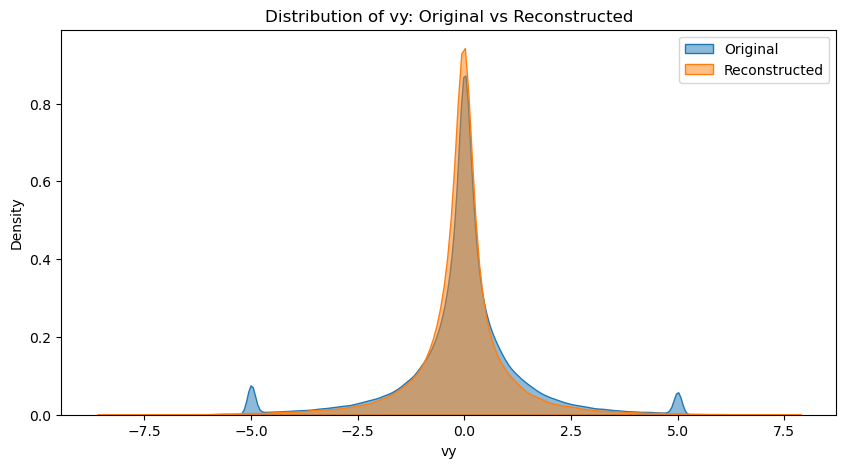

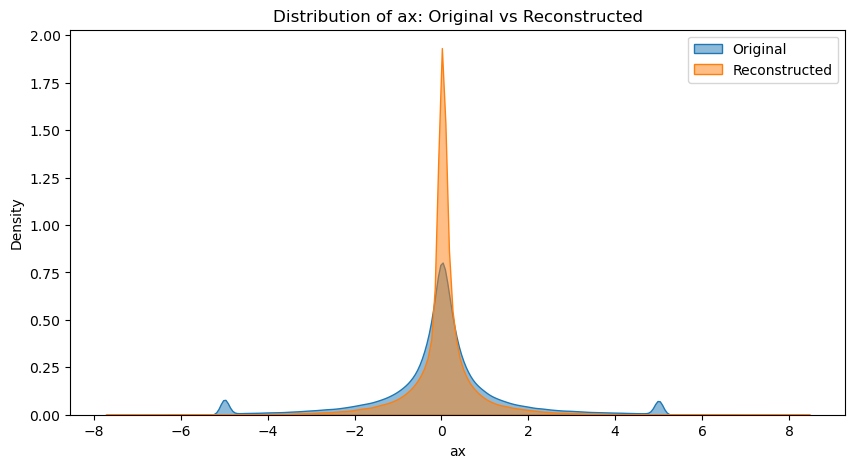

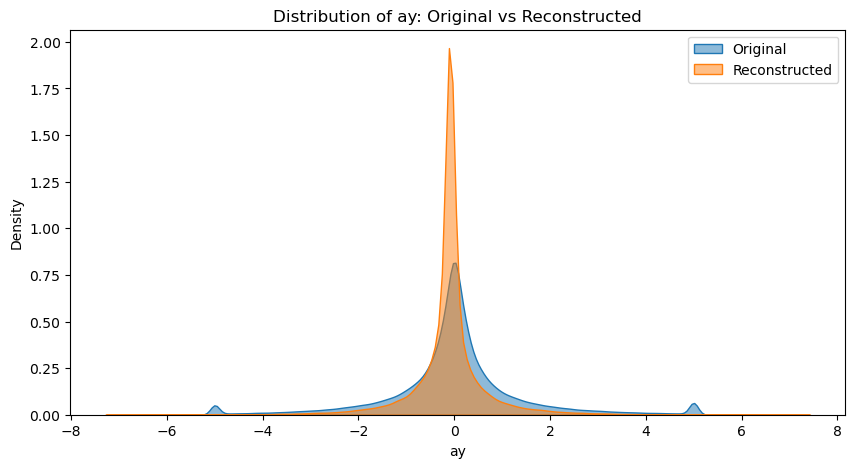

In [20]:
#plot the distribution of original vs reconstructed data
import matplotlib.pyplot as plt
import seaborn as sns
for col in df_validation_output.columns:
    plt.figure(figsize=(10,5))
    sns.kdeplot(df_all_data[col], label="Original", fill=True, alpha=0.5)
    sns.kdeplot(df_validation_output[col], label="Reconstructed", fill=True, alpha=0.5)
    plt.title(f"Distribution of {col}: Original vs Reconstructed")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

# Other TCN autoencoder with modified dataset function

In [2]:
from src.embeddings.dataset import WindowDatasetTCN
from src.embeddings.train import train_tcn_ae

## First Check That the Dataset class works

In [3]:
processed_path = "data/processed"
paths = [os.path.join(processed_path, f) for f in os.listdir(processed_path) if f.endswith("30fps_processed.pkl")]

df_dict = {}
cols_to_keep = ['frame', 'hand_label', 'cx_smooth', 'cy_smooth']

with tqdm(total=len(paths), desc="Loading processed data") as pbar:
    for path in paths:
        vid = os.path.basename(path).replace("_30fps_processed.pkl", "")
        vid = vid.replace("hand_tracking_", "")
        df_dict[vid] = pd.read_pickle(path)[cols_to_keep]
        pbar.update(1)

Loading processed data: 100%|██████████| 86/86 [00:34<00:00,  2.51it/s]


In [4]:
dataset = WindowDatasetTCN(df_dict, hand="Right", feature_mode="pos_vel_acc", window_size=90, step_size=30, orig_fps=30.0, scaling=True)

Processing Right Hand Windows: 100%|██████████| 86/86 [00:00<00:00, 96.06it/s] 


Computing scaling statistics from training data...


In [8]:
dataset[0][0]

tensor([[-0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00,  0.0000e+00,
         -0.0000e+00,  0.0000e+00],
        [ 0.0000e+00, -0.0000e+00,  0.0000e+00, -0.0000e+00,  0.0000e+00,
         -0.0000e+00,  0.0000e+00],
        [ 1.5087e+00, -4.6047e+00,  1.5087e+00, -4.6049e+00,  3.9479e-01,
          4.3950e+00,  1.0000e+00],
        [ 1.3498e+00, -1.7434e+00,  1.3498e+00, -1.7435e+00, -5.4350e-01,
          9.3230e+00,  1.0000e+00],
        [ 1.0930e+00, -4.0059e+00,  1.0930e+00, -4.0061e+00, -8.9448e-01,
         -7.4283e+00,  1.0000e+00],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00,  0.0000e+00,
         -0.0000e+00,  0.0000e+00],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00,  0.0000e+00,
         -0.0000e+00,  0.0000e+00],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00,  0.0000e+00,
         -0.0000e+00,  0.0000e+00],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00,  0.0000e+00,
         -0.0000e+00,  0.0000e+00],
        [ 

In [6]:
ae, _ = train_tcn_ae(dataset, feature_dim=7, latent_dim=16,
             batch_size=32, epochs=20, lr=1e-3, device="cpu")

Epoch 001: 100%|██████████| 1100/1100 [01:25<00:00, 12.88it/s]


Epoch 001 — loss: 0.601497


Epoch 002: 100%|██████████| 1100/1100 [01:31<00:00, 12.00it/s]


Epoch 002 — loss: 0.537886


Epoch 003: 100%|██████████| 1100/1100 [01:35<00:00, 11.52it/s]


...

Epoch 011 — loss: 0.410934


Epoch 012: 100%|██████████| 1100/1100 [01:31<00:00, 12.07it/s]


Epoch 012 — loss: 0.407395


Epoch 013:   2%|▏         | 20/1100 [00:01<01:31, 11.82it/s]


KeyboardInterrupt: 